In [202]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [39]:
#PHASE 1

In [40]:
df = pd.read_csv('loan_default_dataset.csv')
df

,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Annual_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Existing_Loans_Count,Debt_to_Income_Ratio,Payment_History,Savings_Balance,Loan_Purpose,Default
0,CUST00000,59,Male,Single,High School,Unemployed,153435,57032,36,337,0,0.16,Poor,3594,Car,1
1,CUST00001,49,Male,Single,Bachelor,Unemployed,1358590,753454,24,799,3,0.52,Average,77610,Business,1
2,CUST00002,35,Male,Married,Bachelor,Employed,864995,350178,60,342,1,0.22,Average,189727,Home,1
3,CUST00003,63,Male,Married,Master,Unemployed,862917,676946,12,816,1,0.66,Good,421647,Education,1
4,CUST00004,28,Female,Married,High School,Unemployed,525601,957555,24,367,1,0.23,Average,214756,Home,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CUST01995,54,Female,Married,PhD,Unemployed,523221,969156,36,881,2,0.13,Average,270189,Car,0
1996,CUST01996,38,Male,Married,Master,Employed,1184023,486841,48,832,2,0.53,Poor,306399,Car,1
1997,CUST01997,33,Male,Married,High School,Self-Employed,946060,308466,24,434,1,0.65,Average,52965,Education,1
1998,CUST01998,61,Female,Single,High School,Unemployed,543545,529198,60,410,4,0.31,Poor,264381,Personal,1


In [41]:
print("Shape of dataset:",df.shape)

Shape of dataset: (2000, 16)


In [42]:
print("Size of dataset:",df.size)

Size of dataset: 32000


In [43]:
#Understanding the structure of dataset
df.describe()

,Age,Annual_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Existing_Loans_Count,Debt_to_Income_Ratio,Savings_Balance,Default
count,2000.000000,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,42.694000,8.299711e+05,525997.057000,36.354000,596.964000,1.974500,0.400720,247342.831500,0.69550
std,12.614195,3.862774e+05,272378.273758,17.087442,171.731356,1.420161,0.171901,143678.727557,0.46031
min,21.000000,1.500370e+05,50799.000000,12.000000,300.000000,0.000000,0.100000,1056.000000,0.00000
25%,32.000000,5.106692e+05,296489.750000,24.000000,452.000000,1.000000,0.250000,124489.250000,0.00000
50%,43.000000,8.314425e+05,525436.000000,36.000000,593.000000,2.000000,0.400000,249331.000000,1.00000
75%,54.000000,1.153992e+06,770494.000000,48.000000,748.000000,3.000000,0.542500,369349.250000,1.00000
max,64.000000,1.499987e+06,999500.000000,60.000000,899.000000,4.000000,0.700000,499901.000000,1.00000


In [44]:
#Counting total null values in each column using null function
print("Total null values in each column:",df.isna().sum())
#Counting total null values in dataset
print("Total null values in dataset:",df.isna().sum().sum())

Total null values in each column: Customer_ID             0
Age                     0
Gender                  0
Marital_Status          0
Education_Level         0
Employment_Status       0
Annual_Income           0
Loan_Amount             0
Loan_Term_Months        0
Credit_Score            0
Existing_Loans_Count    0
Debt_to_Income_Ratio    0
Payment_History         0
Savings_Balance         0
Loan_Purpose            0
Default                 0
dtype: int64
Total null values in dataset: 0


In [45]:
#Checking for duplicates
print("Duplicated rows:",df.duplicated().sum())

Duplicated rows: 0


In [46]:
#Checking necessary features needed
print("Column names:\n",df.columns)
df.head()

Column names:
 Index(['Customer_ID', 'Age', 'Gender', 'Marital_Status', 'Education_Level',
       'Employment_Status', 'Annual_Income', 'Loan_Amount', 'Loan_Term_Months',
       'Credit_Score', 'Existing_Loans_Count', 'Debt_to_Income_Ratio',
       'Payment_History', 'Savings_Balance', 'Loan_Purpose', 'Default'],
      dtype='object')


,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Annual_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Existing_Loans_Count,Debt_to_Income_Ratio,Payment_History,Savings_Balance,Loan_Purpose,Default
0,CUST00000,59,Male,Single,High School,Unemployed,153435,57032,36,337,0,0.16,Poor,3594,Car,1
1,CUST00001,49,Male,Single,Bachelor,Unemployed,1358590,753454,24,799,3,0.52,Average,77610,Business,1
2,CUST00002,35,Male,Married,Bachelor,Employed,864995,350178,60,342,1,0.22,Average,189727,Home,1
3,CUST00003,63,Male,Married,Master,Unemployed,862917,676946,12,816,1,0.66,Good,421647,Education,1
4,CUST00004,28,Female,Married,High School,Unemployed,525601,957555,24,367,1,0.23,Average,214756,Home,1


In [47]:
#Dropping columns which are not required
df=df.drop(columns = ['Customer_ID','Gender'])

In [48]:
df

,Age,Marital_Status,Education_Level,Employment_Status,Annual_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Existing_Loans_Count,Debt_to_Income_Ratio,Payment_History,Savings_Balance,Loan_Purpose,Default
0,59,Single,High School,Unemployed,153435,57032,36,337,0,0.16,Poor,3594,Car,1
1,49,Single,Bachelor,Unemployed,1358590,753454,24,799,3,0.52,Average,77610,Business,1
2,35,Married,Bachelor,Employed,864995,350178,60,342,1,0.22,Average,189727,Home,1
3,63,Married,Master,Unemployed,862917,676946,12,816,1,0.66,Good,421647,Education,1
4,28,Married,High School,Unemployed,525601,957555,24,367,1,0.23,Average,214756,Home,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,54,Married,PhD,Unemployed,523221,969156,36,881,2,0.13,Average,270189,Car,0
1996,38,Married,Master,Employed,1184023,486841,48,832,2,0.53,Poor,306399,Car,1
1997,33,Married,High School,Self-Employed,946060,308466,24,434,1,0.65,Average,52965,Education,1
1998,61,Single,High School,Unemployed,543545,529198,60,410,4,0.31,Poor,264381,Personal,1


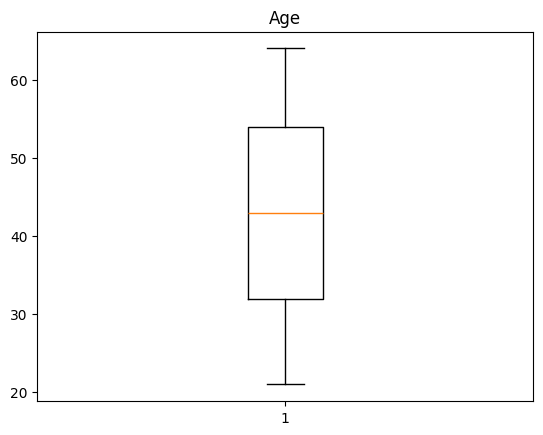

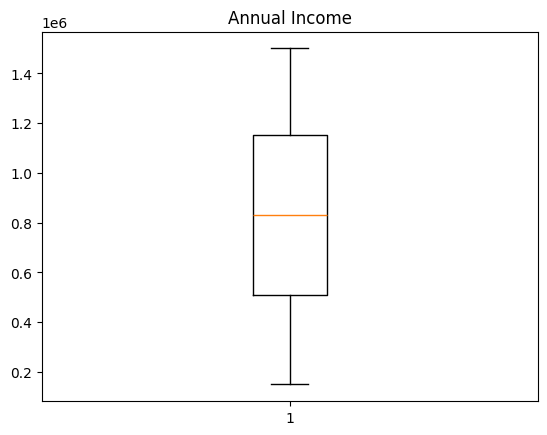

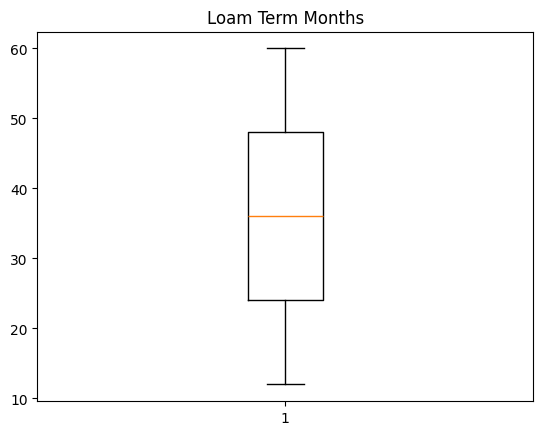

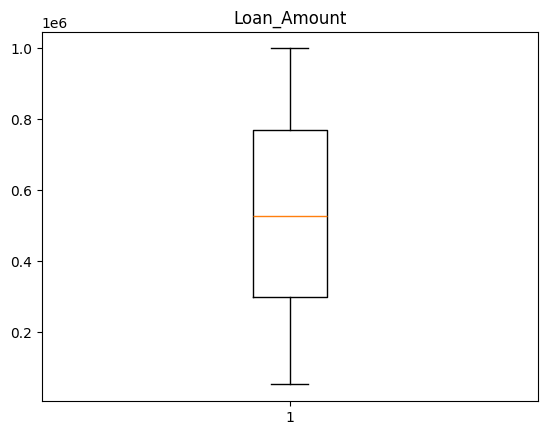

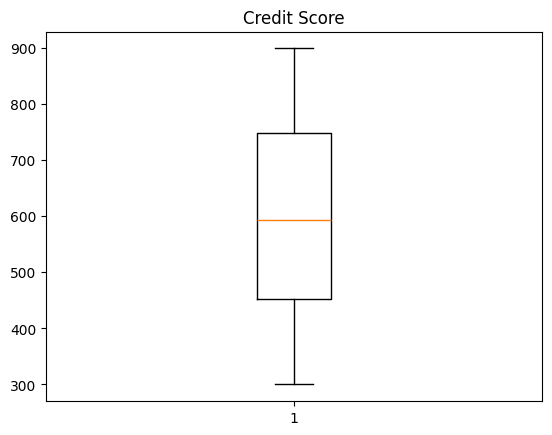

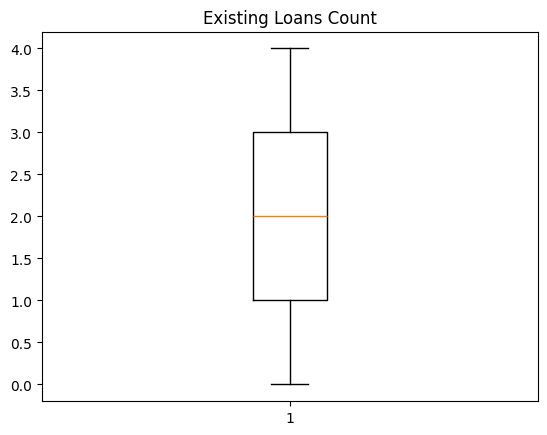

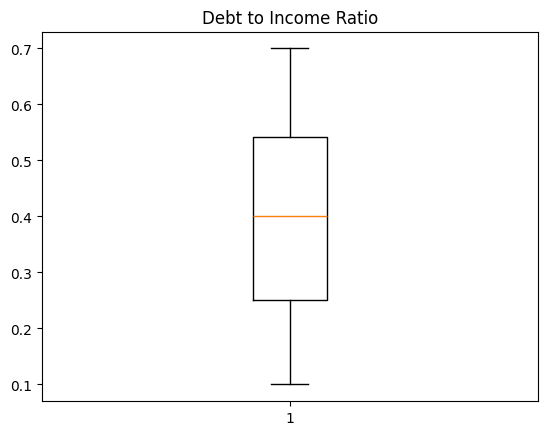

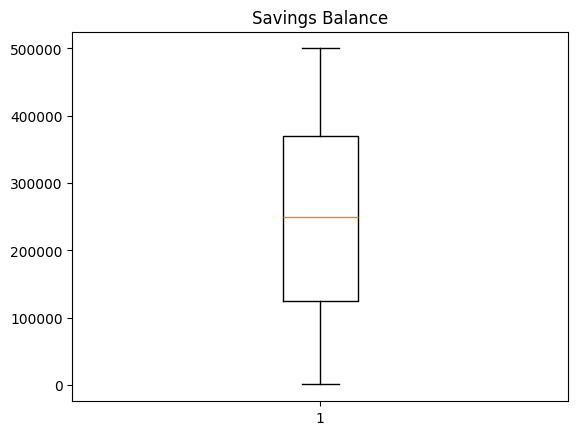

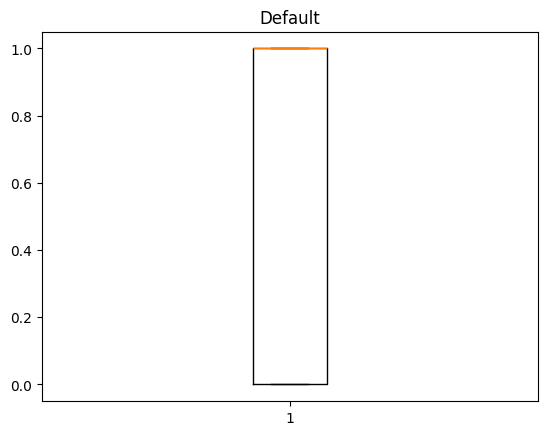

In [49]:
#Outlier Detection by boxplot

plt.boxplot(df['Age'])
plt.title('Age')
plt.show()

plt.boxplot(df['Annual_Income'])
plt.title('Annual Income')
plt.show()

plt.boxplot(df['Loan_Term_Months'])
plt.title('Loam Term Months')
plt.show()

plt.boxplot(df['Loan_Amount'])
plt.title('Loan_Amount')
plt.show()

plt.boxplot(df['Credit_Score'])
plt.title('Credit Score')
plt.show()

plt.boxplot(df['Existing_Loans_Count'])
plt.title('Existing Loans Count')
plt.show()

plt.boxplot(df['Debt_to_Income_Ratio'])
plt.title('Debt to Income Ratio')
plt.show()

plt.boxplot(df['Savings_Balance'])
plt.title('Savings Balance')
plt.show()

plt.boxplot(df['Default'])
plt.title('Default')
plt.show()

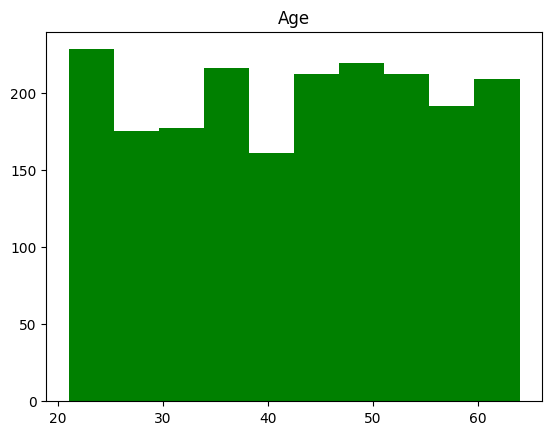

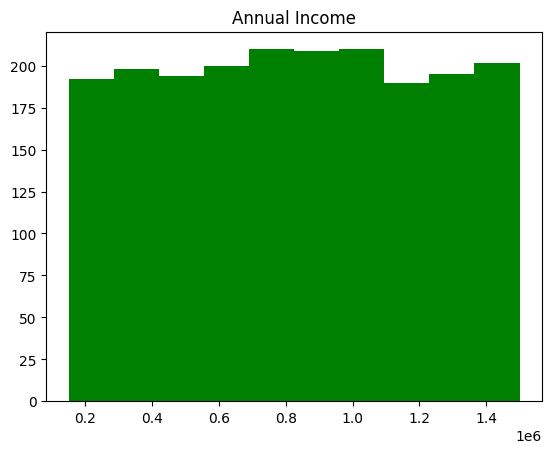

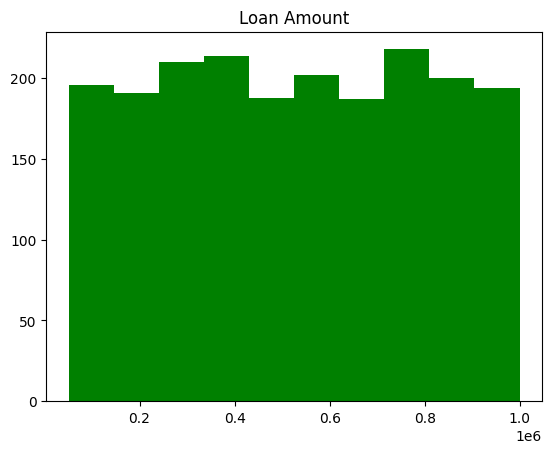

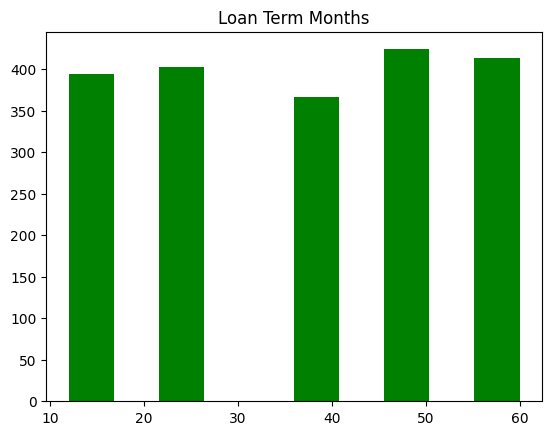

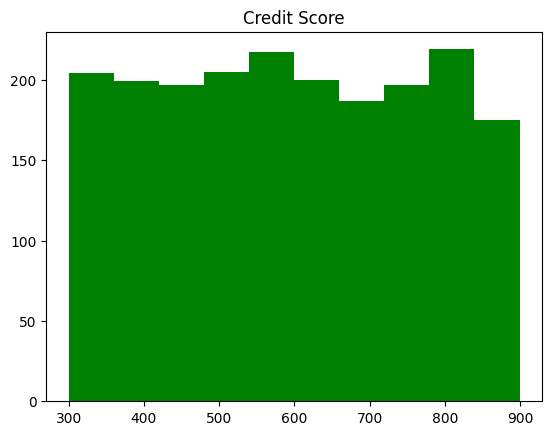

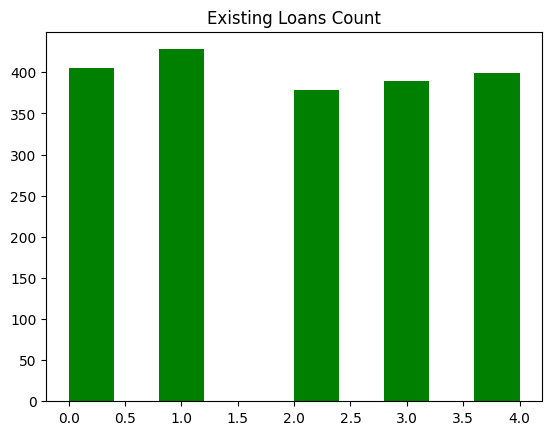

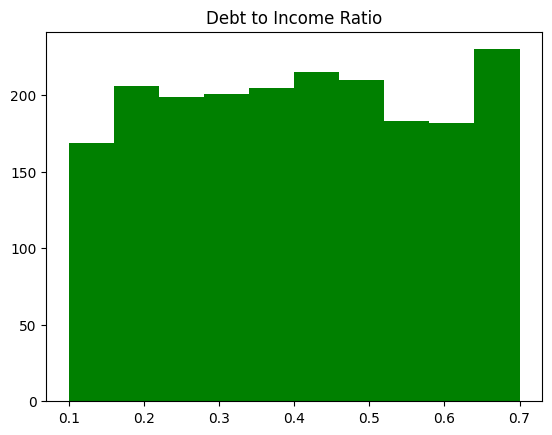

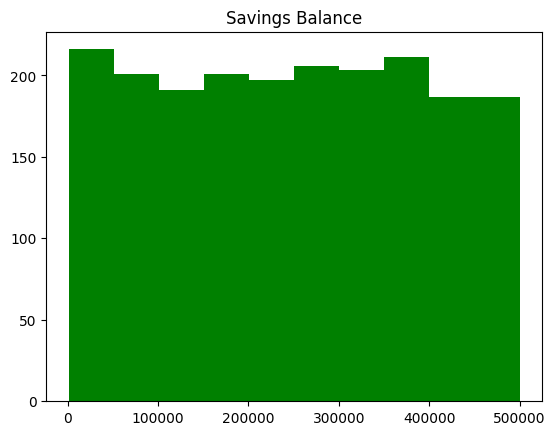

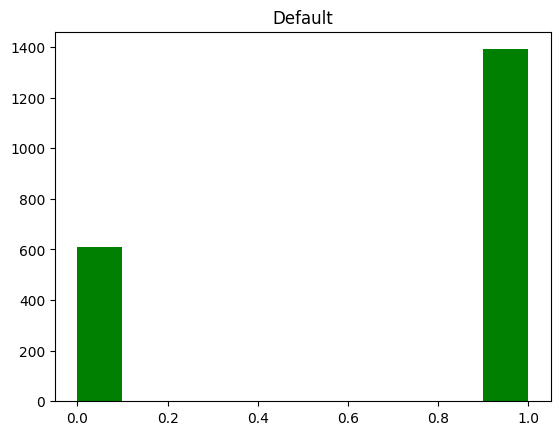

In [50]:
#Checking data distribution by histogram

plt.hist(df['Age'],color='g')
plt.title('Age')
plt.show()

plt.hist(df['Annual_Income'],color='g')
plt.title('Annual Income')
plt.show()

plt.hist(df['Loan_Amount'],color='g')
plt.title('Loan Amount')
plt.show()

plt.hist(df['Loan_Term_Months'],color='g')
plt.title('Loan Term Months')
plt.show()

plt.hist(df['Credit_Score'],color='g')
plt.title('Credit Score')
plt.show()

plt.hist(df['Existing_Loans_Count'],color='g')
plt.title('Existing Loans Count')
plt.show()

plt.hist(df['Debt_to_Income_Ratio'],color='g')
plt.title('Debt to Income Ratio')
plt.show()

plt.hist(df['Savings_Balance'],color='g')
plt.title('Savings Balance')
plt.show()

plt.hist(df['Default'],color='g')
plt.title('Default')
plt.show()

In [233]:
#Scaling the features using MinMaxScaler
mm = MinMaxScaler()
normalized_data = pd.DataFrame(mm.fit_transform(df[['Annual_Income', 'Loan_Amount', 'Loan_Term_Months',
       'Credit_Score', 'Existing_Loans_Count', 'Debt_to_Income_Ratio', 'Savings_Balance']]))

normalized_data

,0,1,2,3,4,5,6
0,0.002517,0.006570,0.50,0.061770,0.00,0.100000,0.005088
1,0.895258,0.740650,0.25,0.833055,0.75,0.700000,0.153462
2,0.529618,0.315567,1.00,0.070117,0.25,0.200000,0.378216
3,0.528079,0.660005,0.00,0.861436,0.25,0.933333,0.843130
4,0.278206,0.955787,0.25,0.111853,0.25,0.216667,0.428390
...,...,...,...,...,...,...,...
1995,0.276443,0.968015,0.50,0.969950,0.50,0.050000,0.539512
1996,0.765944,0.459620,0.75,0.888147,0.50,0.716667,0.612100
1997,0.589669,0.271600,0.25,0.223706,0.25,0.916667,0.104058
1998,0.291498,0.504267,1.00,0.183639,1.00,0.350000,0.527869


In [204]:
#Dimensionality Reduction using PCA
pca = PCA()
X_scaled = pd.DataFrame(pca.fit_transform(standardized_data))
X_scaled

,0,1,2,3,4,5,6
0,-0.383629,0.371479,-0.507410,-0.779780,-0.347855,0.235417,0.013760
1,0.029733,-0.360446,-0.085166,0.387506,0.293993,0.058948,-0.483447
2,0.069976,0.597884,0.037835,-0.466875,-0.127452,-0.109082,-0.111273
3,-0.474706,-0.361725,0.139566,0.488032,0.239818,0.054327,0.333063
4,-0.382326,0.042578,-0.096566,0.036792,-0.600980,-0.285486,-0.120955
...,...,...,...,...,...,...,...
1995,0.066791,-0.015142,0.142381,0.446830,-0.552359,0.399187,-0.106723
1996,0.166153,0.107020,0.211659,0.265386,0.392526,0.186935,0.022140
1997,-0.406248,-0.030429,-0.420203,-0.204099,0.395746,-0.185974,-0.092926
1998,0.681009,0.162822,-0.089304,-0.201908,-0.247434,-0.248067,0.061553


In [205]:

#Comparing shape after dimensionality reduction
print("Shape before applying PCA:", standardized_data.shape)
print("Shape after applying PCA:",X_scaled.shape)

Shape before applying PCA: (2000, 7)
Shape after applying PCA: (2000, 7)


In [206]:
#Explained Variance
print("Explained variance:\n",pca.explained_variance_ratio_)

Explained variance:
 [0.19422924 0.19052517 0.13044856 0.12518999 0.12292917 0.1199902
 0.11668767]


In [235]:
#Naming scaled columns using rename function

print("Scaled data:\n")

X_scaled.rename(columns={0:'Annual_Income',
1:'Loan_Amount',
2:'Loan_Term_Months',
3:'Credit_Score',
4:'Existing_Loan_Count',
5:'Debt_to_Income_Ratio',
6:'Savings_Balance'},inplace = True)

normalized_data.head()

Scaled data:



,0,1,2,3,4,5,6
0,0.002517,0.006570,0.50,0.061770,0.00,0.100000,0.005088
1,0.895258,0.740650,0.25,0.833055,0.75,0.700000,0.153462
2,0.529618,0.315567,1.00,0.070117,0.25,0.200000,0.378216
3,0.528079,0.660005,0.00,0.861436,0.25,0.933333,0.843130
4,0.278206,0.955787,0.25,0.111853,0.25,0.216667,0.428390


In [208]:
#Using train test split by using Scaled data

X = X_scaled
Y = df['Default']
Y

,Default
0,1
1,1
2,1
3,1
4,1
...,...
1995,0
1996,1
1997,1
1998,1


In [209]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

print("Successfully Executed")

Successfully Executed


In [210]:
#PHASE 2

In [241]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [242]:

#Model training with the help of KNeighborsClassifier
Model1 = KNeighborsClassifier(n_neighbors = 3)

In [243]:
Model1.fit(X_train,Y_train)

KNeighborsClassifier(n_neighbors=3)

In [244]:
#Checking the prediction of the model
Y_pred = knn.predict(X_test)
print("Predicted Values:\n",Y_pred)

Predicted Values:
 [0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 1 1
 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 1 0 1 0 0 0 1 0 0 1 0 0 1 0 0 1 0
 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 1 1 1 0 0 1 1 1 0 1 1 1 0 0 1 0 1 0
 1 0 1 0 1 0 1 1 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1
 1 1 1 0 0 1 1 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 0
 0 0 0 0 1 1 1 0 0 1 1 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 1 0 1 1 0 1 0 1 1 1 0
 1 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1 0 1 0 1 0 1 0
 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0 1 0 1 0 0 0 0 1 1 0 0 1 0 0
 0 1 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1
 1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 1 1 1 0 1 1 1
 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 1 0 0 1]


In [245]:
#Checking scores of KNeighborsClassifier model
F1 = f1_score(Y_test,Y_pred)
P = precision_score(Y_test,Y_pred)
R = recall_score(Y_test,Y_pred)

In [246]:
print(f"Precision score:{p_score}\n")
print(f"Recall score:{r_score}\n\nF1 score:{F1}")

Precision score:0.8073770491803278

Recall score:0.7433962264150943

F1 score:0.48226950354609927


In [247]:
print("Classification reports of KNeighborsClassifier:\n", classification_report(Y_test,Y_pred))

Classification reports of KNeighborsClassifier:
               precision    recall  f1-score   support

           0       0.33      0.59      0.42       135
           1       0.65      0.38      0.48       265

    accuracy                           0.45       400
   macro avg       0.49      0.49      0.45       400
weighted avg       0.54      0.45      0.46       400



In [249]:
#Training our model through logistic regression
Model2 = LogisticRegression()

In [250]:
Model2.fit(X_train,Y_train)

LogisticRegression()

In [251]:
Y_pred1 = Model2.predict(X_test)
print("Predicted Values:\n",Y_pred1)

Predicted Values:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1
 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0
 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1
 1 1 0 1 1 0 0 0 1 1 0 1 1 0 0 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 1 1 1 0 0 1
 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 0 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0
 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 1 0 1 1 0]


In [252]:
#Checking scores of KNeighborsClassifier model
F1 = f1_score(Y_test,Y_pred1)
P = precision_score(Y_test,Y_pred1)
R = recall_score(Y_test,Y_pred1)
A = accuracy_score(Y_test,Y_pred1)

In [253]:
print("Accuracy score:",A,"\n")
print(f"Precision score:{p_score}\n")
print(f"Recall score:{r_score}\n\nF1 score:{F1}")

Accuracy score: 0.7475 

Precision score:0.8073770491803278

Recall score:0.7433962264150943

F1 score:0.8261617900172117


In [255]:
print("Classification reports of LogisticRegression:\n", classification_report(Y_test,Y_pred1))

Classification reports of LogisticRegression:
               precision    recall  f1-score   support

           0       0.70      0.44      0.54       135
           1       0.76      0.91      0.83       265

    accuracy                           0.75       400
   macro avg       0.73      0.67      0.68       400
weighted avg       0.74      0.75      0.73       400



In [257]:
#Using Standard scaler and applying PCA on it
from sklearn.preprocessing import StandardScaler